# CKD Prediction — Reproducible EDA and Model Notebook
Primary dataset: CKD_NHANES_2021_2023.

**Important:** `egfr`, `ckd_stage`, and `participant_id` are excluded from the primary model to reduce leakage/definition overlap.

In [1]:
import pandas as pd, numpy as np
df=pd.read_csv('../data/CKD_NHANES_2021_2023.csv')
df.loc[df.age<1,'age']=np.nan
df.shape, df.isna().sum().sum(), df.ckd_present.value_counts()

((11933, 29),
 np.int64(114582),
 ckd_present
 1    8341
 0    3592
 Name: count, dtype: int64)

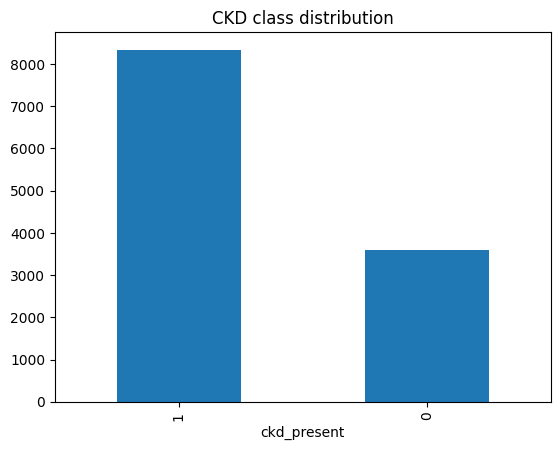

In [2]:
import matplotlib.pyplot as plt
df.ckd_present.value_counts().plot(kind='bar', title='CKD class distribution'); plt.show()

In [3]:
df.groupby('ckd_present')[['serum_creatinine','blood_urea_nitrogen','albumin_creatinine_ratio','bp_systolic']].agg(['count','mean','median']).round(3)

serum_creatinine                ... bp_systolic                
                       count   mean median  ...       count     mean median
ckd_present                                 ...                            
0                       3592  0.757   0.74  ...        3470  116.228  114.0
1                       2734  1.024   0.97  ...        4047  121.913  119.0

[2 rows x 12 columns]

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
X=df.drop(columns=['participant_id','ckd_present','ckd_stage','egfr']); y=df.ckd_present.astype(int)
cat=X.select_dtypes(include=['object']).columns.tolist(); num=X.select_dtypes(exclude=['object']).columns.tolist()
pre=ColumnTransformer([('num',SimpleImputer(strategy='median'),num),('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(handle_unknown='ignore'))]),cat)])
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
models=[XGBClassifier(n_estimators=200,max_depth=6,learning_rate=.1,subsample=.8,colsample_bytree=.8,tree_method='hist',eval_metric='logloss',random_state=42), LGBMClassifier(n_estimators=500,num_leaves=63,learning_rate=.03,subsample=.8,colsample_bytree=1.0,min_child_samples=20,random_state=42,verbosity=-1)]
for model in models:
    pipe=Pipeline([('prep',pre),('model',model)]); pipe.fit(Xtr,ytr); print(type(model).__name__, pipe.score(Xte,yte))

XGBClassifier 0.9949727691663176


LGBMClassifier 0.9958106409719313


/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
